In [1]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from typing import Dict, Tuple, List
import time
import numpy as np
from IPython import display # Jupyter環境用（オプション）

# 環境設定
GRID_SIZE = 10
NUM_AGENTS = 2
NUM_ORDERS = 3
PICKUP_LOCATIONS = [(1, 1), (8, 1), (5, 8)]
DROPOFF_LOCATION = (5, 5)

class WarehouseEnv:
    def __init__(self, size: int = GRID_SIZE, num_agents: int = NUM_AGENTS):
        self.size = size
        self.num_agents = num_agents
        self.action_space = 5  # 0:待機, 1:上, 2:下, 3:左, 4:右

        # Matplotlib用の図の保持
        self.fig = None
        self.ax = None

        # 状態の初期化
        self.reset()

    def reset(self) -> Dict[int, Tuple]:
        """環境を初期化し、初期状態を返します。"""
        self.agent_positions: Dict[int, Tuple[int, int]] = {
            i: (random.randint(0, self.size - 1), random.randint(0, self.size - 1))
            for i in range(self.num_agents)
        }
        self.agent_holding: Dict[int, bool] = {i: False for i in range(self.num_agents)}
        self.remaining_orders: List[int] = list(range(NUM_ORDERS))
        return self._get_obs()

    def _get_obs(self) -> Dict[int, Tuple]:
        obs = {}
        for i in range(self.num_agents):
            obs[i] = (
                self.agent_positions[i],
                self.agent_holding[i],
                tuple(self.remaining_orders)
            )
        return obs

    def step(self, actions: Dict[int, int]) -> Tuple[Dict, Dict, Dict, Dict]:
        next_positions: Dict[int, Tuple[int, int]] = {}
        rewards: Dict[int, float] = {i: -0.1 for i in range(self.num_agents)}

        # 1. 位置の更新
        for i, action in actions.items():
            current_x, current_y = self.agent_positions[i]
            next_x, next_y = current_x, current_y

            if action == 1: next_y += 1  # 上
            elif action == 2: next_y -= 1  # 下
            elif action == 3: next_x -= 1  # 左
            elif action == 4: next_x += 1  # 右

            next_x = np.clip(next_x, 0, self.size - 1)
            next_y = np.clip(next_y, 0, self.size - 1)
            next_positions[i] = (next_x, next_y)

        # 2. 衝突判定
        final_positions = self.agent_positions.copy()
        is_collision = False

        for i in range(self.num_agents):
            pos = next_positions[i]
            is_colliding = False
            for j in range(self.num_agents):
                if i != j and pos == next_positions[j]:
                    is_colliding = True
                    break
            if is_colliding:
                rewards[i] -= 5.0
                is_collision = True
            else:
                final_positions[i] = pos

        self.agent_positions = final_positions

        # 3. ピックアップ・ドロップオフ
        for i in range(self.num_agents):
            current_pos = self.agent_positions[i]
            if not self.agent_holding[i]:
                for order_idx in self.remaining_orders:
                    if current_pos == PICKUP_LOCATIONS[order_idx]:
                        self.agent_holding[i] = True
                        self.remaining_orders.remove(order_idx)
                        rewards[i] += 10.0
                        break
            elif self.agent_holding[i]:
                if current_pos == DROPOFF_LOCATION:
                    self.agent_holding[i] = False
                    rewards[i] += 50.0

        done = {i: len(self.remaining_orders) == 0 for i in range(self.num_agents)}
        return self._get_obs(), rewards, done, {"collision": is_collision}

    # --- 追加された可視化メソッド ---
    def render(self, mode='text', sleep_time=0.5):
        """
        環境を可視化します。
        mode='text': コンソールに文字で表示
        mode='graphic': Matplotlibで図として表示
        """
        if mode == 'text':
            self._render_text()
        elif mode == 'graphic':
            self._render_graphic(sleep_time)

    def _render_text(self):
        grid = [['.' for _ in range(self.size)] for _ in range(self.size)]

        # 場所のマーク (y座標は下から上へ増えるため、表示時は反転させるか注意が必要)
        # ここでは (0,0) を左下として扱います
        x, y = DROPOFF_LOCATION
        grid[self.size - 1 - y][x] = 'D'  # Dropoff

        for idx in self.remaining_orders:
            x, y = PICKUP_LOCATIONS[idx]
            grid[self.size - 1 - y][x] = 'P'  # Pickup

        for i, pos in self.agent_positions.items():
            x, y = pos
            char = f'A{i}'
            if self.agent_holding[i]:
                char = f'H{i}' # Holding

            # 同じ場所に重なった場合の表示処理（簡易）
            if grid[self.size - 1 - y][x] not in ['.', 'P', 'D']:
                grid[self.size - 1 - y][x] += char
            else:
                grid[self.size - 1 - y][x] = char

        print("-" * (self.size * 3))
        for row in grid:
            print(" ".join([f"{c:>2}" for c in row]))
        print("-" * (self.size * 3))

    def _render_graphic(self, sleep_time):
        if self.fig is None:
            plt.ion() # インタラクティブモードON
            self.fig, self.ax = plt.subplots(figsize=(6, 6))

        self.ax.clear()
        self.ax.set_xlim(-0.5, self.size - 0.5)
        self.ax.set_ylim(-0.5, self.size - 0.5)
        self.ax.set_xticks(range(self.size))
        self.ax.set_yticks(range(self.size))
        self.ax.grid(True)
        self.ax.set_title(f"Orders Remaining: {len(self.remaining_orders)}")

        # ドロップオフ地点 (赤色)
        dx, dy = DROPOFF_LOCATION
        self.ax.add_patch(patches.Rectangle((dx-0.5, dy-0.5), 1, 1, color='red', alpha=0.3, label='Dropoff'))
        self.ax.text(dx, dy, 'Drop', ha='center', va='center', fontsize=8, color='darkred')

        # ピックアップ地点 (青色)
        for idx in self.remaining_orders:
            px, py = PICKUP_LOCATIONS[idx]
            self.ax.add_patch(patches.Rectangle((px-0.5, py-0.5), 1, 1, color='blue', alpha=0.3, label='Pickup'))
            self.ax.text(px, py, 'Pick', ha='center', va='center', fontsize=8, color='darkblue')

        # エージェント (円)
        colors = ['green', 'orange', 'purple', 'cyan']
        for i, pos in self.agent_positions.items():
            ax, ay = pos
            color = colors[i % len(colors)]
            # 荷物を持っている場合は枠線を太く、色を変えるなどの表現
            edgecolor = 'black'
            linewidth = 1
            if self.agent_holding[i]:
                linewidth = 3
                edgecolor = 'red' # 荷物持ち強調

            circle = patches.Circle((ax, ay), 0.3, facecolor=color, edgecolor=edgecolor, linewidth=linewidth, label=f'Agent {i}')
            self.ax.add_patch(circle)
            self.ax.text(ax, ay, f'A{i}', ha='center', va='center', color='white', fontweight='bold')

        plt.draw()
        plt.pause(sleep_time)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RNNAgent(nn.Module):
    def __init__(self, input_shape, hidden_dim, n_actions):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_actions = n_actions

        # 観測を入力とする線形層
        self.fc1 = nn.Linear(input_shape, hidden_dim)
        # 履歴を扱うGRUセル
        self.rnn = nn.GRUCell(hidden_dim, hidden_dim)
        # 隠れ状態から行動のQ値を出力する線形層
        self.fc2 = nn.Linear(hidden_dim, n_actions)

    def init_hidden(self):
        # 隠れ状態をゼロで初期化
        return self.fc1.weight.new_zeros(1, self.hidden_dim)

    def forward(self, inputs, hidden_state):
        # inputs: 局所的な観測 (obs_i)
        # hidden_state: 前ステップの隠れ状態 (h_t-1)

        x = F.relu(self.fc1(inputs))
        # GRUによる隠れ状態の更新
        h_in = hidden_state.reshape(-1, self.hidden_dim)
        h = self.rnn(x, h_in)
        # Q値の出力
        q = self.fc2(h)
        return q, h # Q値と新しい隠れ状態を返す

#

In [8]:
class QMixer(nn.Module):
    def __init__(self, n_agents, state_shape, mixing_embed_dim, hypernet_embed_dim):
        super().__init__()
        self.n_agents = n_agents
        self.mixing_embed_dim = mixing_embed_dim
        # 1. ハイパーネットワークの定義
        # 環境状態 (state) を入力とし、Mixing Networkの重みW1を生成
        self.hyper_w1 = nn.Sequential(
            nn.Linear(state_shape, hypernet_embed_dim),
            nn.ReLU(),
            nn.Linear(hypernet_embed_dim, mixing_embed_dim * n_agents)
        )

        # バイアスb1も環境状態から生成
        self.hyper_b1 = nn.Linear(state_shape, mixing_embed_dim)

        # W2 (Mixing Networkの2層目の重み) を生成
        self.hyper_w2 = nn.Sequential(
            nn.Linear(state_shape, hypernet_embed_dim),
            nn.ReLU(),
            nn.Linear(hypernet_embed_dim, mixing_embed_dim)
        )

        # バイアスb2 (最終出力層のバイアス) を環境状態から生成
        self.hyper_b2 = nn.Sequential(
            nn.Linear(state_shape, hypernet_embed_dim),
            nn.ReLU(),
            nn.Linear(hypernet_embed_dim, 1)
        )

        # 2. 最終出力層（ダミー）
        # 実際にはハイパーネットワークが生成した重みで演算するが、サイズ調整のために定義
        self.V = nn.Sequential(nn.Linear(state_shape, mixing_embed_dim), nn.ReLU(), nn.Linear(mixing_embed_dim, 1))

    def forward(self, agent_qs, states):
        # agent_qs: 全エージェントのQ値 (batch_size, n_agents)
        # states: 環境の全体状態 (batch_size, state_shape)

        bs = agent_qs.size(0)

        # 1. 隠れ層 W1 の計算 (重みの生成と非負制約)
        W1 = self.hyper_w1(states).view(bs, self.n_agents, self.mixing_embed_dim)
        # 非負制約: 重みをReLUに通す
        W1 = F.relu(W1)

        # 2. 隠れ層 B1 (バイアス) の計算
        B1 = self.hyper_b1(states).view(bs, 1, self.mixing_embed_dim)

        # 3. 第1層の計算: (Q_i * W1) + B1
        # agent_qs: (bs, 1, n_agents), W1: (bs, n_agents, mixing_embed_dim)
        hidden = torch.bmm(agent_qs.unsqueeze(1), W1)
        # hidden: (bs, 1, mixing_embed_dim)
        hidden = F.relu(hidden + B1)

        # 4. 出力層 W2 の計算 (重みの生成と非負制約)
        W2 = self.hyper_w2(states).view(bs, self.mixing_embed_dim, 1)
        # 非負制約: 重みをReLUに通す
        W2 = F.relu(W2)

        # 5. 出力層 B2 (バイアス) の計算
        B2 = self.hyper_b2(states).view(bs, 1, 1)

        # 6. 第2層の計算: (hidden * W2) + B2
        # V(s)項 (全エージェントに共通のバイアス項)
        v = self.V(states).view(bs, 1, 1)

        # 最終的なQ_totの出力
        q_tot = torch.bmm(hidden, W2) + B2 + v
        # q_tot: (batch_size, 1, 1)
        return q_tot.squeeze()

#

In [5]:
from collections import deque
import random

class ReplayBuffer:
    """QMIX学習に必要なトランジションを格納するリプレイバッファ"""
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
        self.capacity = capacity

    def add(self, state, action, reward, next_state, done):
        # 倉庫環境の出力形式を考慮し、エージェントごとの情報を格納
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        if len(self.buffer) < batch_size:
            return None
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

#

In [6]:
# --- QMIX構成要素のインポート（前の回答のクラス定義を仮定） ---
# import torch, torch.nn, torch.nn.functional
# from RNNAgent import RNNAgent
# from QMixer import QMixer
# ... (実際には上記のクラス定義が必要です)

# QMixAgentの学習ロジックを統合するクラス
class IntegratedQMixAgent:
    def __init__(self, env: WarehouseEnv, obs_shape: int, state_shape: int, n_actions: int, lr=5e-4, gamma=0.99, mixing_embed_dim=32):
        self.env = env
        self.n_agents = env.num_agents
        self.n_actions = n_actions
        self.gamma = gamma
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # RNNの隠れ状態をエージェントごとに保持
        self.hidden_states = {i: None for i in range(self.n_agents)}

        # ネットワークの初期化
        self.agent_net = RNNAgent(obs_shape, hidden_dim=64, n_actions=n_actions).to(self.device)
        self.mixer_net = QMixer(self.n_agents, state_shape, mixing_embed_dim, hypernet_embed_dim=64).to(self.device)

        self.target_agent_net = RNNAgent(obs_shape, hidden_dim=64, n_actions=n_actions).to(self.device)
        self.target_mixer_net = QMixer(self.n_agents, state_shape, mixing_embed_dim, hypernet_embed_dim=64).to(self.device)

        self.target_agent_net.load_state_dict(self.agent_net.state_dict())
        self.target_mixer_net.load_state_dict(self.mixer_net.state_dict())

        params = list(self.agent_net.parameters()) + list(self.mixer_net.parameters())
        self.optimizer = torch.optim.Adam(params, lr=lr)

    def init_hidden(self):
        """エピソード開始時に隠れ状態を初期化"""
        for i in range(self.n_agents):
            self.hidden_states[i] = self.agent_net.init_hidden().to(self.device)

    def _obs_to_tensor(self, obs: Dict[int, Tuple], is_state: bool = False):
        """環境の観測/状態をPyTorchテンソルに変換"""
        if is_state:
            # 全体状態 (全エージェントの位置 + 残り注文)
            state_vec = []
            for i in range(self.n_agents):
                state_vec.extend(list(obs[i][0])) # Agent i の位置 (x, y)
                state_vec.append(1.0 if obs[i][1] else 0.0) # Agent i が荷物を持っているか

            # 残り注文のOne-Hotエンコーディング (簡略化)
            remaining_orders_set = set(obs[0][2])
            for order_idx in range(NUM_ORDERS):
                state_vec.append(1.0 if order_idx in remaining_orders_set else 0.0)

            return torch.FloatTensor(state_vec).to(self.device).unsqueeze(0)
        else:
            # 局所観測 (Agent i の位置, 荷物持ち)
            tensors = {}
            for i in range(self.n_agents):
                obs_i = list(obs[i][0]) # 位置 (x, y)
                obs_i.append(1.0 if obs[i][1] else 0.0) # 荷物持ち

                # 敵エージェントの位置や状態も観測に入れる場合はここで拡張するが、ここでは局所観測のみ

                tensors[i] = torch.FloatTensor(obs_i).to(self.device).unsqueeze(0)
            return tensors

    def get_actions(self, obs: Dict[int, Tuple], epsilon: float) -> Dict[int, int]:
        """epsilon-greedy法で行動を選択し、隠れ状態を更新"""
        actions = {}
        if random.random() < epsilon:
            # 探索 (Exploration)
            for i in range(self.n_agents):
                actions[i] = random.randint(0, self.n_actions - 1)
        else:
            # 活用 (Exploitation)
            agent_obs_tensors = self._obs_to_tensor(obs, is_state=False)
            with torch.no_grad():
                for i in range(self.n_agents):
                    q_values, h_new = self.agent_net(agent_obs_tensors[i], self.hidden_states[i])
                    self.hidden_states[i] = h_new # 隠れ状態を更新
                    actions[i] = q_values.max(dim=-1)[1].item()
        return actions

    def learn(self, batch, target_update_interval):
        """バッチからサンプリングし、QMIX損失で学習"""

        # --- データ変換 ---
        # NOTE: 実際の学習では、リプレイバッファに格納する際にRNNの履歴（隠れ状態）も格納するのが一般的ですが、
        # ここでは簡略化し、バッチ内の各ステップを独立したトランジションとして扱います。

        current_state = torch.cat([self._obs_to_tensor(t[0], is_state=True) for t in batch], dim=0)
        next_state = torch.cat([self._obs_to_tensor(t[3], is_state=True) for t in batch], dim=0)
        rewards = torch.FloatTensor([sum(t[2].values()) for t in batch]).to(self.device) # チーム合計報酬
        terminated = torch.FloatTensor([all(t[4].values()) for t in batch]).to(self.device) # 終了フラグ

        # エージェントごとのアクション、観測をバッチ化
        actions_batch = torch.LongTensor([[t[1][i] for i in range(self.n_agents)] for t in batch]).to(self.device)
        obs_batch = [torch.cat([self._obs_to_tensor(t[0], is_state=False)[i] for t in batch], dim=0) for i in range(self.n_agents)]
        next_obs_batch = [torch.cat([self._obs_to_tensor(t[3], is_state=False)[i] for t in batch], dim=0) for i in range(self.n_agents)]

        # 1. 現在のQ_totの計算 (Hidden Stateはここではゼロ初期化)
        agent_qs = []
        for i in range(self.n_agents):
            # Q値を計算
            q_vals, _ = self.agent_net(obs_batch[i], self.agent_net.init_hidden().expand(len(batch), -1))
            # 実行されたアクションのQ値を選択
            chosen_q = torch.gather(q_vals, dim=1, index=actions_batch[:, i].unsqueeze(1))
            agent_qs.append(chosen_q)

        agent_qs = torch.cat(agent_qs, dim=1) # (batch_size, n_agents)
        q_tot = self.mixer_net(agent_qs, current_state)

        # 2. TDターゲットの計算 (Target Q_tot)
        target_agent_qs = []
        with torch.no_grad():
            for i in range(self.n_agents):
                target_q_vals, _ = self.target_agent_net(next_obs_batch[i], self.target_agent_net.init_hidden().expand(len(batch), -1))
                # 最大Q値を選択
                target_max_q = target_q_vals.max(dim=1)[0].unsqueeze(1)
                target_agent_qs.append(target_max_q)

            target_agent_qs = torch.cat(target_agent_qs, dim=1)
            target_q_tot = self.target_mixer_net(target_agent_qs, next_state)

        # ターゲット値: R + gamma * max Q_next * (1 - done)
        td_target = rewards.unsqueeze(1) + self.gamma * target_q_tot * (1 - terminated.unsqueeze(1))

        # 3. 損失の計算と最適化
        loss = F.mse_loss(q_tot, td_target.detach())

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def update_target_networks(self):
        """ターゲットネットワークの重みを更新"""
        self.target_agent_net.load_state_dict(self.agent_net.state_dict())
        self.target_mixer_net.load_state_dict(self.mixer_net.state_dict())

--- QMIX Learning Start --- (Agents: 2, Grid: 10x10)


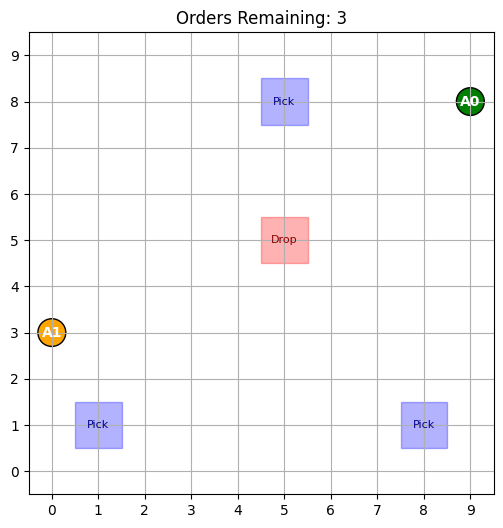

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

/tmp/ipython-input-2611040031.py:126: UserWarning: Using a target size (torch.Size([32, 32])) that is different to the input size (torch.Size([32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(q_tot, td_target.detach())


<Figure size 640x480 with 0 Axes>

Episode: 0/5000, Steps: 200, Avg. Reward (100): 0.00, Epsilon: 0.99, Avg. Loss: 7.1888
Episode: 10/5000, Steps: 2138, Avg. Reward (100): -4.33, Epsilon: 0.95, Avg. Loss: 27.8720
Episode: 20/5000, Steps: 4105, Avg. Reward (100): -11.48, Epsilon: 0.90, Avg. Loss: 219.4433
Episode: 30/5000, Steps: 6059, Avg. Reward (100): -14.25, Epsilon: 0.85, Avg. Loss: 945.3856
Episode: 40/5000, Steps: 8059, Avg. Reward (100): -16.14, Epsilon: 0.80, Avg. Loss: 2302.7197
Episode: 50/5000, Steps: 10059, Avg. Reward (100): -23.17, Epsilon: 0.75, Avg. Loss: 4684.7958
Episode: 60/5000, Steps: 12059, Avg. Reward (100): -28.06, Epsilon: 0.70, Avg. Loss: 3551.9666
Episode: 70/5000, Steps: 14059, Avg. Reward (100): -34.39, Epsilon: 0.65, Avg. Loss: 3909.2820
Episode: 80/5000, Steps: 16059, Avg. Reward (100): -41.50, Epsilon: 0.60, Avg. Loss: 2082.8431
Episode: 90/5000, Steps: 17997, Avg. Reward (100): -44.50, Epsilon: 0.55, Avg. Loss: 7203.4422
Episode: 100/5000, Steps: 19997, Avg. Reward (100): -51.89, Epsilon

In [ ]:
# --- 学習パラメータ ---
MAX_EPISODES = 5000
MAX_STEPS_PER_EPISODE = 200
BATCH_SIZE = 32
REPLAY_CAPACITY = 50000
TARGET_UPDATE_INTERVAL = 200 # ステップ数でターゲットネットワークを更新
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 40000

# 環境とエージェントの準備
env = WarehouseEnv()

# --- 観測/状態のサイズを計算 ---
# 局所観測: (x, y, holding) -> 3
OBS_SHAPE = 3
# 全体状態: (A0のx, A0のy, A0のholding, A1のx, A1のy, A1のholding, P0_status, P1_status, P2_status) -> 2*3 + 3 = 9
STATE_SHAPE = env.num_agents * 3 + NUM_ORDERS
ACTION_SPACE = env.action_space

# QMixAgentの初期化
agent = IntegratedQMixAgent(env, OBS_SHAPE, STATE_SHAPE, ACTION_SPACE)
replay_buffer = ReplayBuffer(REPLAY_CAPACITY)

total_steps = 0
episode_rewards = []
losses = []

print(f"--- QMIX Learning Start --- (Agents: {NUM_AGENTS}, Grid: {GRID_SIZE}x{GRID_SIZE})")

for episode in range(MAX_EPISODES):
    obs = env.reset()
    agent.init_hidden()

    current_state_obs = obs # ステップ前の状態を格納 (ログ用)
    episode_reward = 0
    done = {i: False for i in range(env.num_agents)}

    for step in range(MAX_STEPS_PER_EPISODE):
        total_steps += 1

        # 1. epsilonの減衰
        epsilon = max(EPSILON_END, EPSILON_START - (total_steps / EPSILON_DECAY))

        # 2. 行動の選択
        actions = agent.get_actions(current_state_obs, epsilon)

        # 3. 環境との相互作用
        next_obs, rewards, done, info = env.step(actions)

        # 4. リプレイバッファに格納 (全体状態としてログに記録)
        # NOTE: QMIXではRNNの隠れ状態も格納することが推奨されますが、ここでは簡略化
        replay_buffer.add(current_state_obs, actions, rewards, next_obs, done)

        # 5. 学習 (バッファが十分溜まったら実行)
        if len(replay_buffer) > BATCH_SIZE * 5 and total_steps % 4 == 0:
            batch = replay_buffer.sample(BATCH_SIZE)
            loss = agent.learn(batch, TARGET_UPDATE_INTERVAL)
            losses.append(loss)

            # ターゲットネットワークの更新
            if total_steps % TARGET_UPDATE_INTERVAL == 0:
                agent.update_target_networks()

        # 報酬の集計と状態の更新
        episode_reward += sum(rewards.values())
        current_state_obs = next_obs

        # 可視化 (任意)
        if episode % 500 == 0 and step % 20 == 0:
            env.render(mode='graphic', sleep_time=0.01)

        if all(done.values()):
            break

    episode_rewards.append(episode_reward)

    # ログ出力
    if episode % 10 == 0:
        avg_reward = np.mean(episode_rewards[-100:])
        avg_loss = np.mean(losses[-100:]) if losses else 0
        print(f"Episode: {episode}/{MAX_EPISODES}, Steps: {total_steps}, Avg. Reward (100): {avg_reward:.2f}, Epsilon: {epsilon:.2f}, Avg. Loss: {avg_loss:.4f}")

print("--- QMIX Learning Finished ---")

# 学習結果のプロット (任意)
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards)
plt.title("Episode Reward History")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

In [ ]:
def run_learned_agent(agent: IntegratedQMixAgent, env: WarehouseEnv, max_steps: int = 100, render_mode: str = 'graphic', sleep_time: float = 0.5):
    """
    学習済みエージェントを環境内で実行し、その動作を可視化する。

    Args:
        agent (IntegratedQMixAgent): 学習済みのQMIXエージェントインスタンス。
        env (WarehouseEnv): 倉庫環境インスタンス。
        max_steps (int): エピソードの最大ステップ数。
        render_mode (str): 'graphic' または 'text'。
        sleep_time (float): 各ステップ間の待機時間（グラフィックモード時）。
    """

    print("\n--- Running Learned Agent (Greedy Policy) ---")

    # 1. 環境の初期化
    obs = env.reset()
    agent.init_hidden() # エピソード開始時に隠れ状態をリセット
    current_state_obs = obs

    episode_reward = 0
    done = {i: False for i in range(env.num_agents)}

    # 2. ネットワークを評価モードに設定 (ドロップアウトなどを無効化)
    agent.agent_net.eval()

    for step in range(max_steps):
        # 3. 行動の選択 (epsilon=0、貪欲法)
        # 実行時はHidden Stateの更新も必要
        actions = agent.get_actions(current_state_obs, epsilon=0.0) # 探索なし

        # 4. 環境との相互作用
        next_obs, rewards, done, info = env.step(actions)

        # 5. 可視化
        if render_mode == 'graphic':
            env.render(mode='graphic', sleep_time=sleep_time)
        else:
            env.render(mode='text', sleep_time=0.0)

        # 6. 報酬の集計と状態の更新
        episode_reward += sum(rewards.values())
        current_state_obs = next_obs

        print(f"Step {step+1}: Actions={actions}, Total Reward={sum(rewards.values()):.1f}, Cum. Reward={episode_reward:.1f}")

        if all(done.values()):
            print(f"--- Episode Finished at Step {step+1} (Total Reward: {episode_reward:.1f}) ---")
            break

    if not all(done.values()):
        print(f"--- Episode Finished by Timeout (Max Steps: {max_steps}) (Total Reward: {episode_reward:.1f}) ---")

    # 評価モードを解除 (念のため)
    agent.agent_net.train()

run_learned_agent(
    agent=agent,
    env=env,
    max_steps=200,
    render_mode='graphic',
    sleep_time=0.3
)